In [52]:
%pip install tqdm
%pip install cvxpy
%pip install --upgrade pip
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
%pip install tqdm
from tqdm import tqdm
from PIL import Image
import os
import gc
import warnings
from funcs import *
%matplotlib inline
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


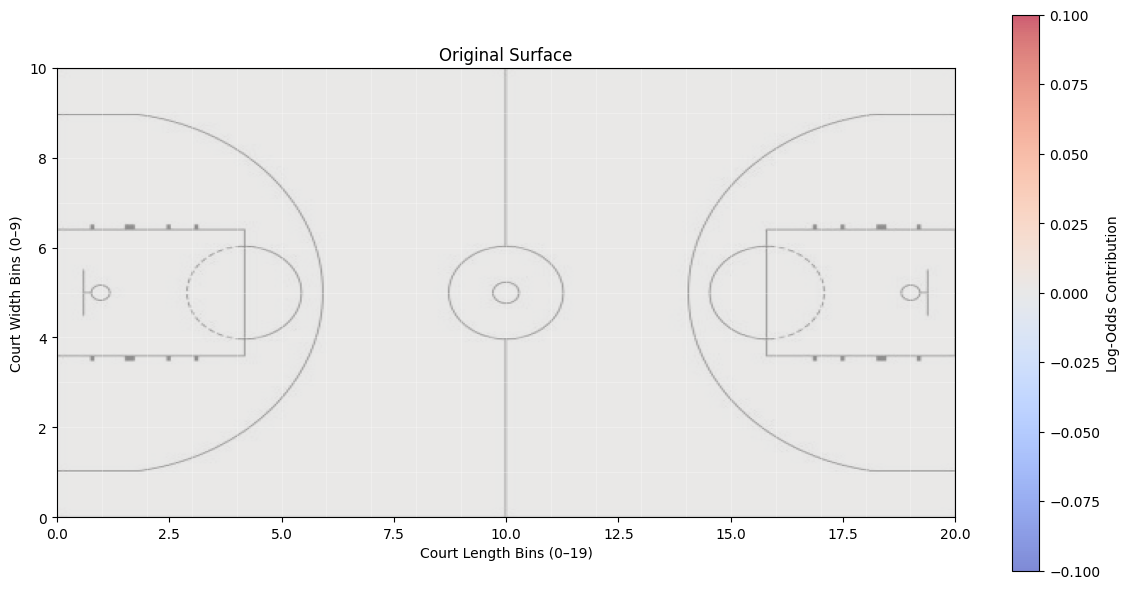

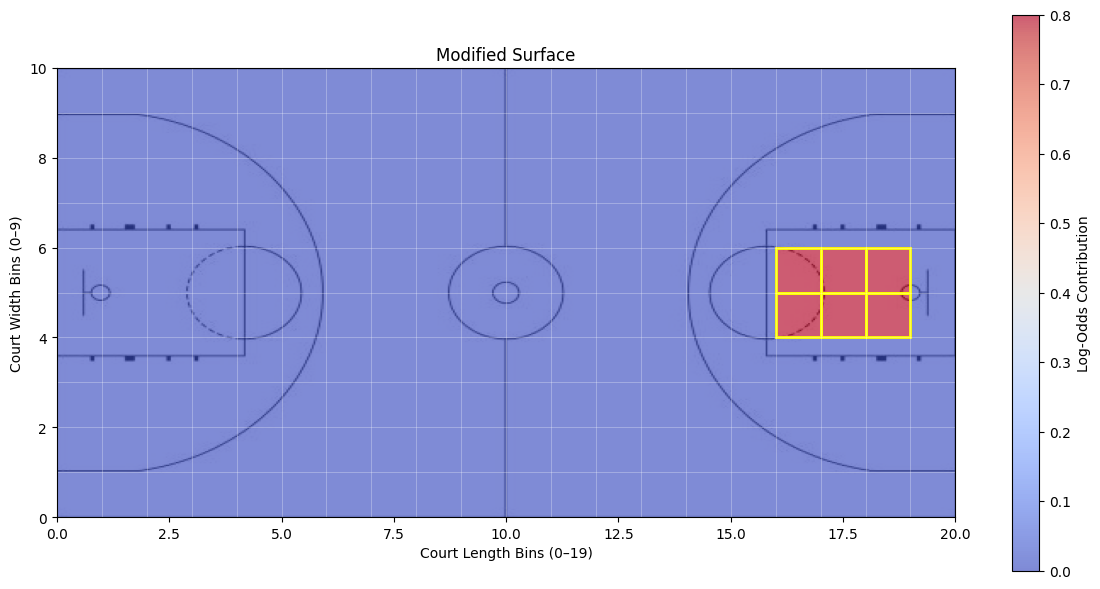

In [54]:
# -------------------------------------------------
# COURT SETTINGS
# -------------------------------------------------

x_bins = 20
y_bins = 10

court_img = Image.open("court.jpg")

# -------------------------------------------------
# 1. CREATE BLANK LOG-ODDS MATRIX
# -------------------------------------------------

# Each cell represents a sector's contribution to scoring log-odds
propensity_matrix = np.zeros((x_bins, y_bins))

# -------------------------------------------------
# 2. FUNCTION TO MODIFY SECTORS
# -------------------------------------------------

def build_range_updates(length_range, width_range, value):
    x_start, x_end = length_range
    y_start, y_end = width_range

    return {
        (x, y): value
        for x in range(x_start, x_end + 1)
        for y in range(y_start, y_end + 1)
    }


def adjust_sector_propensity(matrix, updates, mode="add"):
    
    new_matrix = matrix.copy()

    for (x, y), value in updates.items():

        if mode == "add":
            new_matrix[x, y] += value

        elif mode == "set":
            new_matrix[x, y] = value

        else:
            raise ValueError("mode must be 'add' or 'set'")

    return new_matrix


# -------------------------------------------------
# 3. PLOT FUNCTION
# -------------------------------------------------

def plot_surface(matrix, title="Sector Log-Odds Surface", changed=None):

    fig, ax = plt.subplots(figsize=(12,6))

    ax.imshow(court_img, extent=[0,x_bins,0,y_bins], aspect="auto")

    img = ax.imshow(
        matrix.T,
        origin="lower",
        cmap="coolwarm",
        extent=[0,x_bins,0,y_bins],
        alpha=0.65
    )

    # grid lines
    for x in range(x_bins+1):
        ax.axvline(x,color="white",lw=0.5,alpha=0.4)

    for y in range(y_bins+1):
        ax.axhline(y,color="white",lw=0.5,alpha=0.4)

    # highlight changed sectors
    if changed is not None:
        for (x,y) in changed:
            rect = Rectangle((x,y),1,1,
                             fill=False,
                             edgecolor="yellow",
                             lw=2)
            ax.add_patch(rect)

    plt.colorbar(img, ax=ax, label="Log-Odds Contribution")

    ax.set_xlim(0,x_bins)
    ax.set_ylim(0,y_bins)

    ax.set_title(title)
    ax.set_xlabel("Court Length Bins (0–19)")
    ax.set_ylabel("Court Width Bins (0–9)")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# 4. EXAMPLE: BATCH MODIFY A RANGE OF SECTORS
# -------------------------------------------------

length_range = (16, 18)
width_range = (4, 5)
value = 0.8

updates = build_range_updates(length_range, width_range, value)

modified_matrix = adjust_sector_propensity(
    propensity_matrix,
    updates,
    mode="set"
)

# -------------------------------------------------
# 5. PLOT ORIGINAL AND MODIFIED
# -------------------------------------------------

plot_surface(propensity_matrix, "Original Surface")

plot_surface(modified_matrix,
             "Modified Surface",
             changed=updates.keys())

# Example for multiple batch updates:
# updates = {}
# updates.update(build_range_updates((16, 18), (4, 5), 0.8))
# updates.update(build_range_updates((18, 19), (2, 3), -0.4))

In [55]:
# Adjust the matrix for time, and move hot/cold sectors around
# Create fake games, ~100 samples per game
# Simulate where they scored or not, adjust danger zones to reflect the actual scoring rate
# Play with matrix to reflect actual scoring
# Sectors increase likelihood of scoring
# Check out Codex

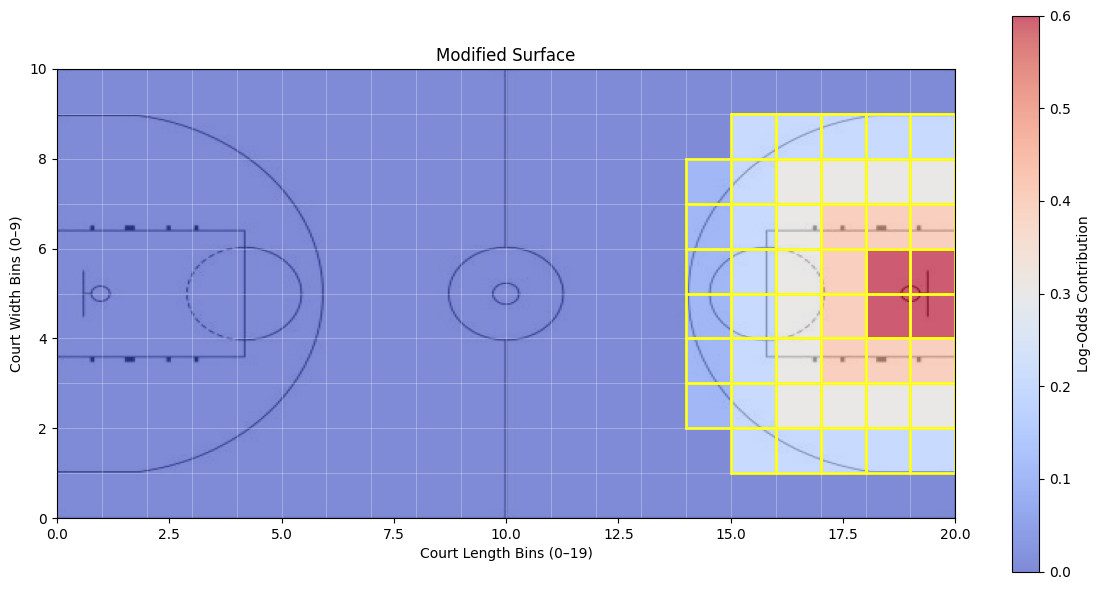

In [56]:
updates = {}

def wrap(x_1, x_2, y_1, y_2, val ,square):
    global modified_matrix

    updates.update(build_range_updates((x_1, x_1), (y_1, y_2), val))

    if (square == True): 
        updates.update(build_range_updates((x_2, x_2), (y_1, y_2), val))

    updates.update(build_range_updates((x_1, x_2), (y_1, y_1), val))
    updates.update(build_range_updates((x_1, x_2), (y_2, y_2), val))

    #return modified_matrix
    
updates.update(build_range_updates((18, 19), (4, 5), .6))
updates.update(build_range_updates((14, 14), (2, 7), .1))
wrap(17, 19, 3, 6, .4, False)
wrap(16, 19, 2, 7, .3, False)
wrap(15, 19, 1, 8, .2, False)

modified_matrix = adjust_sector_propensity(
    propensity_matrix,
    updates,
    mode="set"
    )

plot_surface(modified_matrix,
         "Modified Surface",
         changed=updates.keys())

In [57]:
df = pd.read_csv("multi_game_data.csv")

def build_visited_bin_matrices(df, x_bins=20, y_bins=10):
    required_cols = {"game_id", "possession_number", "x_bin", "y_bin", "scored"}
    missing_cols = required_cols.difference(df.columns)

    if missing_cols:
        raise ValueError(f"df is missing required columns: {sorted(missing_cols)}")

    records = []

    grouped = df.groupby(["game_id", "possession_number"], sort=True)
    for (game_id, possession_number), group in grouped:
        # Matrix shape is (x_bins, y_bins): x is the first axis, y is the second.
        visited_matrix = np.zeros((x_bins, y_bins), dtype=np.int8)
        visited_bins = set(zip(group["x_bin"].astype(int), group["y_bin"].astype(int)))

        for xb, yb in visited_bins:
            if 0 <= xb < x_bins and 0 <= yb < y_bins:
                visited_matrix[xb, yb] = 1

        records.append({
            "game_id": game_id,
            "possession_number": possession_number,
            "scored": int(group["scored"].iloc[0]),
            "visited_matrix": visited_matrix
        })

    return pd.DataFrame(records)


visited_bin_matrices = build_visited_bin_matrices(df, x_bins=x_bins, y_bins=y_bins)

# Shape: (n_possessions, x_bins, y_bins)
possession_game_bin_matrix = np.stack(visited_bin_matrices["visited_matrix"].to_numpy())

# Flatten each possession matrix into one design row while preserving x-by-y order.
X = possession_game_bin_matrix.reshape(len(visited_bin_matrices), -1)

# Outcome vector aligned with the stacked possession matrices and flattened design rows.
y = visited_bin_matrices["scored"].to_numpy(dtype=np.int8)


In [58]:
def sample_X_y(X, y, n_samples, replace=True, random_state=None):
    if len(X) != len(y):
        raise ValueError(f"X has {len(X)} rows but y has length {len(y)}")

    rng = np.random.default_rng(random_state)
    sample_idx = rng.choice(len(X), size=n_samples, replace=replace)

    return X[sample_idx], y[sample_idx], sample_idx

X_sample, y_sample, sample_idx = sample_X_y(X, y, n_samples=95, random_state=42)

print("stacked matrix shape:", possession_game_bin_matrix.shape)
print("flattened design shape:", X.shape)
print("outcome shape:", y.shape)
print("sample indices:", sample_idx)

X_sample, y_sample

stacked matrix shape: (902, 20, 10)
flattened design shape: (902, 200)
outcome shape: (902,)
sample indices: [ 80 698 590 395 390 774  77 629 181  84 474 880 663 686 647 709 462 115
 757 406 451 334 164 835 704 580 362 742 491 399 406 204  83 500 800  57
 774 746 249 569 149 683 631 319  61 875 402 805 611 702 685 175 328 420
 449  39 493 139 670 616 832 671 330 872 370 293 816 334  68 423 717 170
 417 117 619 429 297 204 509 604 848 394 144 751 568 631  87 281 692 750
 392 725 759 349 810]


(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(95, 200), dtype=int8),
 array([1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
        0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 0, 1, 0, 1, 1], dtype=int8))

In [59]:
# Flatten betas in the same x-by-y order used to build each row of X.
betas = modified_matrix.reshape(-1)

if X.shape[1] != betas.shape[0]:
    raise ValueError(
        f"X has {X.shape[1]} columns but betas has length {betas.shape[0]}"
    )

logits = X_sample @ betas
propensity_scores = 1 / (1 + np.exp(-logits))

print("X shape:", X.shape)
print("betas shape:", betas.shape)
print("logits shape:", logits.shape)
print("propensity_scores shape:", propensity_scores.shape)

# Avoid above, use below:
# heuristically instead
# baseline: no score
# depending on position, will increase or decrease score
# start with where the play ended, move to full movement
# use proportion of movements in specific zones

X shape: (902, 200)
betas shape: (200,)
logits shape: (95,)
propensity_scores shape: (95,)


In [60]:
propensity_scores

array([0.99550373, 0.89090318, 0.99550373, 0.99849882, 0.93086158,
       0.96442881, 0.76852478, 0.95689275, 0.549834  , 0.9939402 ,
       0.99797468, 0.99752738, 0.99592986, 0.97811873, 0.97068777,
       0.95257413, 0.9939402 , 0.98522597, 0.9900482 , 0.95689275,
       0.9836975 , 0.99959043, 0.99944722, 0.99631576, 0.9836975 ,
       0.9836975 , 0.66818777, 0.85814894, 0.97340301, 0.99899323,
       0.95689275, 0.96083428, 0.97587298, 0.98015969, 0.96442881,
       0.99917558, 0.96442881, 0.97587298, 0.99888746, 0.98661308,
       0.9168273 , 0.64565631, 0.99944722, 0.98787157, 0.97068777,
       0.98015969, 0.99776215, 0.99797468, 0.9900482 , 0.98661308,
       0.99988835, 0.81757448, 0.98015969, 0.90887704, 0.9909867 ,
       0.9900482 , 0.99908895, 0.97811873, 0.85814894, 0.9836975 ,
       0.97068777, 0.99908895, 0.96442881, 0.80218389, 0.99917558,
       0.96442881, 0.99797468, 0.99959043, 0.73105858, 0.9836975 ,
       0.98661308, 0.96083428, 0.9945137 , 0.96770454, 0.94267

In [61]:
#Shelf this for now, develop heuristic method first

In [62]:
cleaned = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

In [63]:
cleaned

,game_id,home_away,is_home,period,time,x,y,z,possession_start,possession_end,possession_number,scored,half_court_crossings
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720.0,703.0,1.0,1.0,1
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720.0,703.0,1.0,1.0,1
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720.0,703.0,1.0,1.0,1
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720.0,703.0,1.0,1.0,1
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720.0,703.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
701940,21500649,home,1,4,21.10,83.69121,22.79488,4.07905,34.0,21.0,86.0,1.0,1
701941,21500649,home,1,4,21.10,83.47899,23.10999,3.94410,34.0,21.0,86.0,1.0,1
701942,21500649,home,1,4,21.10,83.28644,23.44933,3.79860,34.0,21.0,86.0,1.0,1
701943,21500649,home,1,4,21.10,83.13118,23.82744,3.63053,34.0,21.0,86.0,1.0,1


In [64]:
cleaned_binned = bin_and_flip(cleaned, flip = "yes")
cleaned_binned["sector"] = list(zip(cleaned_binned["x_bin"], cleaned_binned["y_bin"]))
cleaned_binned

,game_id,home_away,is_home,period,time,x,y,z,possession_start,possession_end,possession_number,scored,half_court_crossings,x_bin,y_bin,sector
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720.0,703.0,1.0,1.0,1,7,3,"(7, 3)"
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701940,21500649,home,1,4,21.10,83.69121,22.79488,4.07905,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"
701941,21500649,home,1,4,21.10,83.47899,23.10999,3.94410,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"
701942,21500649,home,1,4,21.10,83.28644,23.44933,3.79860,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"
701943,21500649,home,1,4,21.10,83.13118,23.82744,3.63053,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"


In [65]:
possession_cols = ["game_id", "possession_number"]


def build_visited_possessions(
    binned_df,
    possession_cols=possession_cols,
    sector_col="sector",
    scored_col="scored",
    sample_interval_seconds=0.04,
    last_n_unique_visited=5,
):
    required_cols = set(possession_cols) | {sector_col, scored_col}
    missing_cols = required_cols.difference(binned_df.columns)
    if missing_cols:
        raise ValueError(f"binned_df is missing required columns: {sorted(missing_cols)}")

    visited = binned_df.groupby(possession_cols, observed=False)[sector_col].value_counts().reset_index()
    visited["time"] = visited["count"] * sample_interval_seconds
    visited["time_proportion"] = (
        visited["count"]
        / visited.groupby(possession_cols, observed=False)["count"].transform("sum")
    )

    possession_scoring = (
        binned_df.groupby(possession_cols, observed=False)[scored_col].max().reset_index()
    )
    visited = visited.merge(possession_scoring, on=possession_cols, how="left")

    end_sector = (
        binned_df.drop_duplicates(possession_cols, keep="last")
        .assign(is_end_sector=True)[possession_cols + [sector_col, "is_end_sector"]]
    )
    visited = visited.merge(end_sector, on=possession_cols + [sector_col], how="left")
    visited["is_end_sector"] = visited["is_end_sector"].eq(True)

    last_visited_col = f"was_last_{last_n_unique_visited}_visited"
    last_visited = (
        binned_df.drop_duplicates(possession_cols + [sector_col], keep="last")
        .groupby(possession_cols, observed=False)
        .tail(last_n_unique_visited)
        .assign(**{last_visited_col: True})[possession_cols + [sector_col, last_visited_col]]
    )
    visited = visited.merge(last_visited, on=possession_cols + [sector_col], how="left")
    visited[last_visited_col] = visited[last_visited_col].eq(True)

    return visited


visited_posssessions = build_visited_possessions(cleaned_binned)
visited_posssessions




,game_id,possession_number,sector,count,time,time_proportion,scored,is_end_sector,was_last_5_visited
0,21500009,1.0,"(3, 1)",48,1.92,0.091255,1.0,False,False
1,21500009,1.0,"(4, 1)",47,1.88,0.089354,1.0,False,False
2,21500009,1.0,"(12, 3)",37,1.48,0.070342,1.0,False,False
3,21500009,1.0,"(18, 5)",36,1.44,0.068441,1.0,True,True
4,21500009,1.0,"(6, 3)",28,1.12,0.053232,1.0,False,False
...,...,...,...,...,...,...,...,...,...
25217,21500649,86.0,"(15, 6)",8,0.32,0.008377,1.0,False,False
25218,21500649,86.0,"(19, 5)",8,0.32,0.008377,1.0,False,True
25219,21500649,86.0,"(17, 4)",5,0.20,0.005236,1.0,True,True
25220,21500649,86.0,"(3, 5)",4,0.16,0.004188,1.0,False,False


In [66]:
possession_scoring = cleaned_binned.groupby(["game_id", "possession_number"], observed=False)["scored"].max()
scoring_possession_proportion = possession_scoring.mean()
scoring_possession_proportion

np.float64(0.5682989690721649)

In [67]:
def _sector_effect_lookup(sector, effects):
    if effects is None:
        return 0.0

    if isinstance(effects, dict):
        return effects.get(sector, 0.0)

    x_bin, y_bin = sector
    if 0 <= x_bin < effects.shape[0] and 0 <= y_bin < effects.shape[1]:
        return effects[x_bin, y_bin]

    return 0.0


def create_baseline_scoring_probabilities(
    visited_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=None,
    possession_cols=("game_id", "possession_number"),
    sector_col="sector",
    movement_weight_col = None,
    end_indicator_col="is_end_sector",
    scored_col="scored",
):
    required_cols = set(possession_cols) | {sector_col}
    if movement_weight_col is not None:
        required_cols.add(movement_weight_col)
    missing_cols = required_cols.difference(visited_possessions.columns)
    if missing_cols:
        raise ValueError(f"visited_possessions is missing required columns: {sorted(missing_cols)}")

    df = visited_possessions.copy()

    if baseline_probability is None:
        if scored_col not in df.columns:
            raise ValueError("Provide baseline_probability or include a scored column.")
        baseline_probability = df.groupby(list(possession_cols), observed=False)[scored_col].max().mean()

    baseline_probability = np.clip(baseline_probability, 0, 1)
    df["movement_sector_effect"] = df[sector_col].apply(lambda sector: _sector_effect_lookup(sector, movement_effects))
    if movement_weight_col is None:
        df["movement_probability_adjustment"] = df["movement_sector_effect"]
    else:
        df["movement_probability_adjustment"] = df["movement_sector_effect"] * df[movement_weight_col]

    if end_indicator_col in df.columns:
        df["end_sector_effect"] = df[sector_col].apply(lambda sector: _sector_effect_lookup(sector, end_effects))
        df["end_probability_adjustment"] = np.where(df[end_indicator_col], df["end_sector_effect"], 0.0)
    else:
        df["end_probability_adjustment"] = 0.0

    probability_components = (
        df.groupby(list(possession_cols), observed=False)
        .agg(
            movement_probability_adjustment=("movement_probability_adjustment", "sum"),
            end_probability_adjustment=("end_probability_adjustment", "sum"),
        )
        .reset_index()
    )

    probability_components["movement_probability_adjustment"] = (
        probability_components["movement_probability_adjustment"].round(10)
    )
    probability_components["baseline_probability"] = baseline_probability
    probability_components["raw_scoring_probability"] = (
        probability_components["baseline_probability"]
        + probability_components["movement_probability_adjustment"]
        + probability_components["end_probability_adjustment"]
    )
    probability_components["scoring_probability"] = probability_components["raw_scoring_probability"].clip(0, 1)

    if scored_col in df.columns:
        actual_scoring = df.groupby(list(possession_cols), observed=False)[scored_col].max().reset_index()
        probability_components = probability_components.merge(actual_scoring, on=list(possession_cols), how="left")

    return probability_components


# Example effect surfaces. Positive values increase scoring probability; negative values decrease it.
movement_effects = np.zeros((x_bins, y_bins))
end_effects = np.zeros((x_bins, y_bins))

movement_effects[12:17, 0:3] = .04
movement_effects[18:20, 0:4] = .04
movement_effects[14:20, 7:10] = .03
movement_effects[10:15, 2:6] = -.03
movement_effects[15:18, 2:4] = -.03

end_effects[18:20, 4:6] = .20

baseline_scoring_probabilities = create_baseline_scoring_probabilities(
    visited_posssessions,
    movement_effects=movement_effects,
    end_effects=end_effects,
    baseline_probability=.50,
)

baseline_scoring_probabilities

,game_id,possession_number,movement_probability_adjustment,end_probability_adjustment,baseline_probability,raw_scoring_probability,scoring_probability,scored
0,21500009,1.0,-0.15,0.2,0.5,0.55,0.55,1.0
1,21500009,2.0,0.00,0.2,0.5,0.70,0.70,1.0
2,21500009,3.0,0.06,0.2,0.5,0.76,0.76,1.0
3,21500009,4.0,-0.11,0.0,0.5,0.39,0.39,0.0
4,21500009,5.0,-0.27,0.0,0.5,0.23,0.23,0.0
...,...,...,...,...,...,...,...,...
771,21500649,82.0,0.00,0.2,0.5,0.70,0.70,1.0
772,21500649,83.0,0.00,0.2,0.5,0.70,0.70,1.0
773,21500649,84.0,-0.23,0.2,0.5,0.47,0.47,1.0
774,21500649,85.0,-0.24,0.0,0.5,0.26,0.26,0.0


In [68]:
# "training" games and "test" games

train_set = [21500649, 21500390, 21500188, 21500355, 21500057, 21500009]

train = baseline_scoring_probabilities[baseline_scoring_probabilities["game_id"].isin(train_set)]
test = baseline_scoring_probabilities[~baseline_scoring_probabilities["game_id"].isin(train_set)]

train


,game_id,possession_number,movement_probability_adjustment,end_probability_adjustment,baseline_probability,raw_scoring_probability,scoring_probability,scored
0,21500009,1.0,-0.15,0.2,0.5,0.55,0.55,1.0
1,21500009,2.0,0.00,0.2,0.5,0.70,0.70,1.0
2,21500009,3.0,0.06,0.2,0.5,0.76,0.76,1.0
3,21500009,4.0,-0.11,0.0,0.5,0.39,0.39,0.0
4,21500009,5.0,-0.27,0.0,0.5,0.23,0.23,0.0
...,...,...,...,...,...,...,...,...
771,21500649,82.0,0.00,0.2,0.5,0.70,0.70,1.0
772,21500649,83.0,0.00,0.2,0.5,0.70,0.70,1.0
773,21500649,84.0,-0.23,0.2,0.5,0.47,0.47,1.0
774,21500649,85.0,-0.24,0.0,0.5,0.26,0.26,0.0


In [78]:
def sample_possessions_from_games(
    df,
    game_ids,
    n_possessions,
    possession_cols=possession_cols,
    random_state=None,
    reindex_possessions=True,
):
    game_col, possession_col = possession_cols
    game_df = df[df[game_col].isin(game_ids)].copy()
    possession_keys = game_df[possession_cols].drop_duplicates()

    if possession_keys.empty:
        raise ValueError("No possessions found for the requested game_ids.")

    replace = n_possessions > len(possession_keys)
    sampled_keys = possession_keys.sample(
        n=n_possessions,
        replace=replace,
        random_state=random_state,
    ).reset_index(drop=True)

    if reindex_possessions:
        sampled_keys = sampled_keys.assign(_sample_possession_number=lambda x: x.index)
        sampled = sampled_keys.merge(game_df, on=possession_cols, how="left")
        sampled["original_possession_number"] = sampled[possession_col]
        sampled[possession_col] = sampled["_sample_possession_number"]
        return sampled.drop(columns="_sample_possession_number")

    return game_df.merge(sampled_keys, on=possession_cols, how="inner")


def build_baseline_scoring_pipeline(
    df,
    train_games,
    n_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=0.50,
    random_state=None,
    flip="yes",
    movement_weight_col=None,
    reindex_possessions=True,
):
    sampled_movement = sample_possessions_from_games(
        df,
        game_ids=train_games,
        n_possessions=n_possessions,
        random_state=random_state,
        reindex_possessions=reindex_possessions,
    )
    sampled_binned_movement = bin_and_flip(sampled_movement, flip=flip)
    sampled_binned_movement["sector"] = list(
        zip(sampled_binned_movement["x_bin"], sampled_binned_movement["y_bin"])
    )

    sampled_visited_posssessions = build_visited_possessions(sampled_binned_movement)
    sampled_baseline_scoring_probabilities = create_baseline_scoring_probabilities(
        sampled_visited_posssessions,
        movement_effects=movement_effects,
        end_effects=end_effects,
        baseline_probability=baseline_probability,
        movement_weight_col=movement_weight_col,
    )

    return {
        "sampled_movement": sampled_movement,
        "sampled_binned_movement": sampled_binned_movement,
        "qut_movement": sampled_binned_movement,
        "visited_posssessions": sampled_visited_posssessions,
        "baseline_scoring_probabilities": sampled_baseline_scoring_probabilities,
    }


pipeline_input_df = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

movement_effects[12:17, 0:3] = .1
movement_effects[18:20, 0:4] = .1
movement_effects[14:20, 7:10] = .05
movement_effects[10:15, 2:6] = -.05
movement_effects[15:18, 2:4] = -.05

end_effects[18:20, 4:6] = .20

pipeline_results = build_baseline_scoring_pipeline(
    pipeline_input_df,
    train_games=train_set,
    n_possessions=100,
    movement_effects=movement_effects,
    end_effects=end_effects,
    baseline_probability=0.40,
    random_state=43,
)

pipeline_sampled_movement = pipeline_results["sampled_movement"]
pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
pipeline_qut_movement = pipeline_results["qut_movement"] # movement for QUT
pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"] # run bernoulli on outcome probability from this for QUT to generate predetermined profiles


pipeline_qut_movement


,game_id,possession_number,home_away,is_home,period,time,x,y,z,possession_start,possession_end,scored,half_court_crossings,original_possession_number,x_bin,y_bin,sector
0,21500649,0,home,1,2,529.97,94.07766,20.44340,4.16051,530.0,510.0,1.0,1,31.0,19,4,"(19, 4)"
1,21500649,0,home,1,2,529.93,94.24566,20.44044,4.19410,530.0,510.0,1.0,1,31.0,19,4,"(19, 4)"
2,21500649,0,home,1,2,529.89,94.32763,20.43920,4.20819,530.0,510.0,1.0,1,31.0,19,4,"(19, 4)"
3,21500649,0,home,1,2,529.85,94.34072,20.61367,4.16249,530.0,510.0,1.0,1,31.0,19,4,"(19, 4)"
4,21500649,0,home,1,2,529.81,94.44609,20.59224,4.19665,530.0,510.0,1.0,1,31.0,19,4,"(19, 4)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85829,21500057,99,away,0,1,426.18,88.78774,28.28847,4.10271,450.0,426.0,1.0,1,10.0,18,5,"(18, 5)"
85830,21500057,99,away,0,1,426.14,88.84939,28.26357,4.01819,450.0,426.0,1.0,1,10.0,18,5,"(18, 5)"
85831,21500057,99,away,0,1,426.10,89.06620,28.19447,3.84707,450.0,426.0,1.0,1,10.0,18,5,"(18, 5)"
85832,21500057,99,away,0,1,426.06,89.35437,28.23779,3.71778,450.0,426.0,1.0,1,10.0,19,5,"(19, 5)"


In [79]:
pipeline_baseline_scoring_probabilities



,game_id,possession_number,movement_probability_adjustment,end_probability_adjustment,baseline_probability,raw_scoring_probability,scoring_probability,scored
0,21500009,1,0.00,0.0,0.4,0.40,0.40,1.0
1,21500009,6,0.50,0.0,0.4,0.90,0.90,1.0
2,21500009,33,-0.60,0.0,0.4,-0.20,0.00,0.0
3,21500009,34,0.00,0.0,0.4,0.40,0.40,1.0
4,21500009,50,0.00,0.0,0.4,0.40,0.40,1.0
...,...,...,...,...,...,...,...,...
95,21500649,82,0.30,0.0,0.4,0.70,0.70,1.0
96,21500649,84,0.00,0.0,0.4,0.40,0.40,1.0
97,21500649,87,0.15,0.0,0.4,0.55,0.55,0.0
98,21500649,92,-0.25,0.0,0.4,0.15,0.15,1.0
